# 🏥 Data Analytics 101: Análisis de Readmisiones Hospitalarias
## Universidad Iberoamericana, Ciudad de México

---

### Contexto del Proyecto
El hospital enfrenta un desafío operativo crucial: su tasa de readmisiones no planificadas de pacientes diabéticos dentro de 30 días posteriores al alta es una preocupación principal que impacta negativamente el bienestar del paciente y conlleva costosas penalizaciones regulatorias.

**Objetivos de este análisis:**
1. Comprender la estructura, calidad y limitaciones del conjunto de datos
2. Realizar un EDA profundo identificando patrones en readmisiones, recurrencia hospitalaria y duración de estancias
3. Aplicar pruebas estadísticas formales para evaluar hipótesis relevantes
4. Desarrollar modelos estadísticos interpretables para cada fenómeno clínico
5. Comunicar hallazgos clave y recomendaciones de negocio

---

## Setup, Importación de librerias

In [51]:
#FinalProject
#Developer; Andrick Raya
#Course; DA 101
# Librerías de datos y cálculo
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import (
    ttest_ind, mannwhitneyu, f_oneway, kruskal, 
    chi2_contingency, kstest, shapiro, levene,
    poisson, nbinom
)

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno # Librería especializada en análisis de valores faltantes

# Librerías de machine learning y estadística
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, PoissonRegressor
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
df= pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Mostrar información básica
print("📋 INFORMACIÓN DEL DATASET")
print("="*80)
print(f"Dimensiones: {df.shape}")
print(f"Número de registros (admisiones): {df.shape[0]:,}")
print(f"Número de variables: {df.shape[1]}")
print(f"\nPrimeras filas del dataset:")
print(df.head())
print(f"\nÚltimas filas del dataset:")
print(df.tail())

📋 INFORMACIÓN DEL DATASET
Dimensiones: (101766, 50)
Número de registros (admisiones): 101,766
Número de variables: 50

Primeras filas del dataset:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1             

In [4]:
# Información detallada sobre las columnas
print("📊 TIPO DE DATOS Y VALORES FALTANTES")
print("="*80)
print(df.info())

print("\n📈 DESCRIPCIÓN ESTADÍSTICA - VARIABLES NUMÉRICAS")
print("="*80)
print(df.describe())

print("\n📋 DESCRIPCIÓN - VARIABLES CATEGÓRICAS")
print("="*80)
print(df.describe(include='object'))

📊 TIPO DE DATOS Y VALORES FALTANTES
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64


In [6]:
# Variables de interés según la rúbrica
print("🎯 VARIABLES DE INTERÉS PARA EL ANÁLISIS")
print("="*80)

variables_interes = {
    'readmitted': 'Indica si el paciente fue readmitido en los siguientes 30 días',
    'time_in_hospital': 'Días de estancia hospitalaria',
    'number_inpatient': 'Número de admisiones previas en el último año',
    'diag_1': 'Diagnóstico principal (código ICD-9)',
    'diag_2': 'Diagnóstico secundario',
    'diag_3': 'Diagnóstico terciario',
    'age': 'Edad del paciente',
    'gender': 'Género del paciente',
    'race': 'Raza/etnicidad',
    'num_lab_procedures': 'Número de pruebas de laboratorio',
    'num_medications': 'Número de medicamentos prescritos',
    'number_emergency': 'Número de visitas previas a urgencias',
    'change': 'Si hubo cambio en la medicación',
    'diabetesMed': 'Si el paciente recibió medicación para diabetes'
}

for var, desc in variables_interes.items():
    if var in df.columns:
        print(f"✓ {var:20s} - {desc}")
    else:
        print(f"✗ {var:20s} - NO ENCONTRADA")

# Mostrar todas las columnas disponibles
print(f"\n TODAS LAS COLUMNAS DISPONIBLES:")
print(df.columns.tolist())

🎯 VARIABLES DE INTERÉS PARA EL ANÁLISIS
✓ readmitted           - Indica si el paciente fue readmitido en los siguientes 30 días
✓ time_in_hospital     - Días de estancia hospitalaria
✓ number_inpatient     - Número de admisiones previas en el último año
✓ diag_1               - Diagnóstico principal (código ICD-9)
✓ diag_2               - Diagnóstico secundario
✓ diag_3               - Diagnóstico terciario
✓ age                  - Edad del paciente
✓ gender               - Género del paciente
✓ race                 - Raza/etnicidad
✓ num_lab_procedures   - Número de pruebas de laboratorio
✓ num_medications      - Número de medicamentos prescritos
✓ number_emergency     - Número de visitas previas a urgencias
✓ change               - Si hubo cambio en la medicación
✓ diabetesMed          - Si el paciente recibió medicación para diabetes

 TODAS LAS COLUMNAS DISPONIBLES:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', '

---
## 🔍 SECCIÓN 2: Calidad del Dato & Preprocesamiento 

### Objetivo: 
Realizar una evaluación rigurosa de la calidad del dato, identificando valores faltantes, outliers, inconsistencias y realizando transformaciones bien justificadas.

### Paso 2.1: Análisis de Valores Faltantes
# El dataset de UCI Diabetes codifica los faltantes como '?' o 'Unknown'. 
# Debemos estandarizarlos a np.nan para que Pandas los reconozca.

🚨 ANÁLISIS PROFUNDO DE VALORES FALTANTES

📊 Resumen de Variables con Valores Faltantes:
         Variable  Valores_Faltantes  Porcentaje (%)
medical_specialty              49482          49.36%
       payer_code              39455          39.36%
             race               2191           2.19%

📋 Diagnóstico Preliminar de Tratamiento:
   [ALTO RIESGO] medical_specialty: 49.36% -> Candidata a eliminación (demasiada pérdida de información).
   [RIESGO MEDIO] payer_code: 39.36% -> Candidata a imputación avanzada (ej. MICE, KNN).
   [BAJO RIESGO] race: 2.19% -> Candidata a imputación simple o eliminación de filas (listwise deletion).


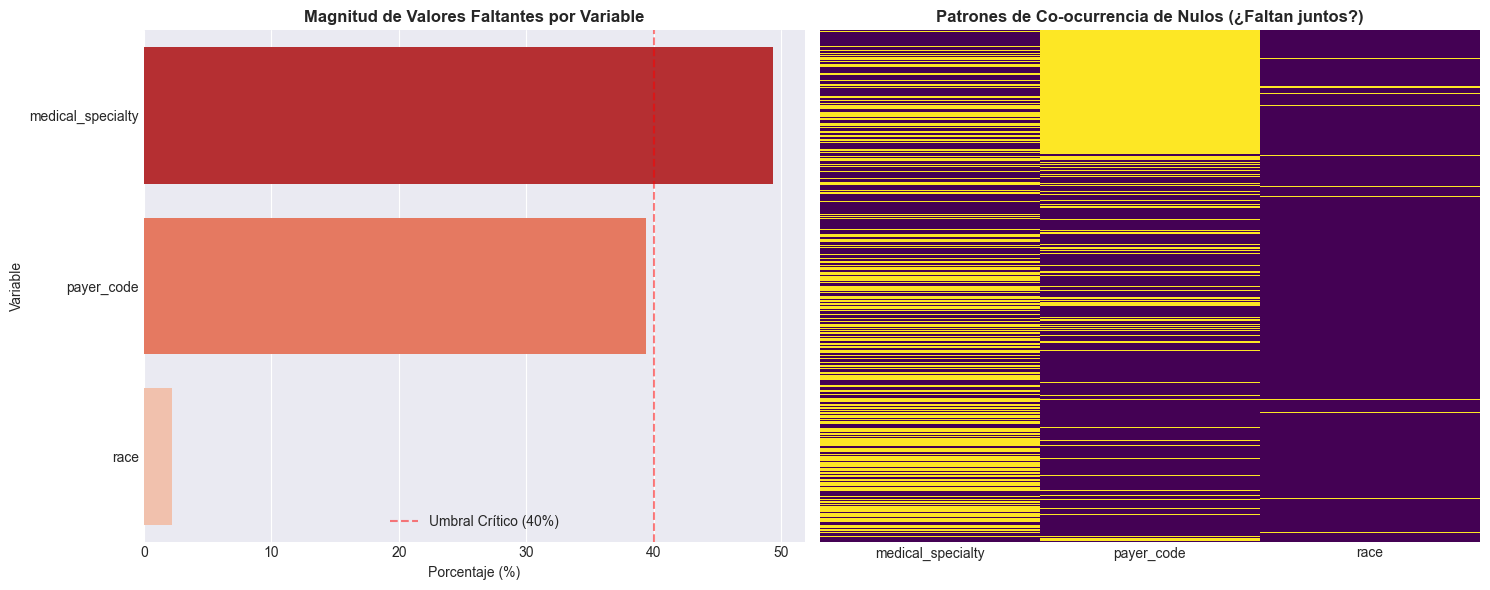


🔗 Análisis de Correlación de Valores Faltantes:
   Si la correlación es cercana a 1 o -1, indica que la ausencia de un dato explica la ausencia de otro (MNAR).


,medical_specialty,payer_code,race
medical_specialty,1.000,-0.135,0.011
payer_code,-0.135,1.000,-0.046
race,0.011,-0.046,1.000


In [52]:
# Análisis de valores faltantes
print("🚨 ANÁLISIS PROFUNDO DE VALORES FALTANTES")
print("="*80)

# 1. Estandarización de Nulos
df_clean = df.copy()
df_clean.replace(['?', 'Unknown', 'None'], np.nan, inplace=True)

# 2. Cuantificación de Missingness
missing_count = df_clean.isnull().sum()
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_df = pd.DataFrame({
    'Variable': df_clean.columns,
    'Valores_Faltantes': missing_count.values,
    'Porcentaje (%)': missing_percent.values
})

# Filtrar solo las que tienen nulos y ordenar
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_df) > 0:
    print("\n📊 Resumen de Variables con Valores Faltantes:")
    print(missing_df.to_string(index=False, float_format=lambda x: f"{x:.2f}%"))
    
    # 3. Clasificación para toma de decisiones
    print("\n📋 Diagnóstico Preliminar de Tratamiento:")
    for index, row in missing_df.iterrows():
        pct = row['Porcentaje (%)']
        var = row['Variable']
        if pct > 40:
            print(f"   [ALTO RIESGO] {var}: {pct:.2f}% -> Candidata a eliminación (demasiada pérdida de información).")
        elif pct > 5:
            print(f"   [RIESGO MEDIO] {var}: {pct:.2f}% -> Candidata a imputación avanzada (ej. MICE, KNN).")
        else:
            print(f"   [BAJO RIESGO] {var}: {pct:.2f}% -> Candidata a imputación simple o eliminación de filas (listwise deletion).")
else:
    print("✓ No hay valores faltantes detectados post-estandarización.")

# 4. Visualización de Mecanismos de Missingness
fig = plt.figure(figsize=(15, 6))

# Subplot 1: Porcentaje de Nulos (Bar chart mejorado)
ax1 = fig.add_subplot(121)
sns.barplot(
    x='Porcentaje (%)', 
    y='Variable', 
    data=missing_df, 
    palette='Reds_r', 
    ax=ax1
)
ax1.set_title('Magnitud de Valores Faltantes por Variable', fontweight='bold')
ax1.set_xlabel('Porcentaje (%)')
ax1.axvline(x=40, color='red', linestyle='--', alpha=0.5, label='Umbral Crítico (40%)')
ax1.legend()

# Subplot 2: Matriz de Nulos (Heatmap de co-ocurrencia)
# Esto nos ayuda a ver si los datos faltan simultáneamente en varias columnas
ax2 = fig.add_subplot(122)
cols_with_missing = missing_df['Variable'].tolist()
sns.heatmap(df_clean[cols_with_missing].isnull(), cbar=False, cmap='viridis', ax=ax2)
ax2.set_title('Patrones de Co-ocurrencia de Nulos (¿Faltan juntos?)', fontweight='bold')
ax2.set_yticks([]) # Ocultar labels del eje Y por ser muchos registros

plt.tight_layout()
plt.show()

# 5. Análisis de Correlación de Nulos
if len(cols_with_missing) > 1:
    print("\n🔗 Análisis de Correlación de Valores Faltantes:")
    print("   Si la correlación es cercana a 1 o -1, indica que la ausencia de un dato explica la ausencia de otro (MNAR).")
    missing_corr = df_clean[cols_with_missing].isnull().corr()
    display(missing_corr.round(3))

La matriz de correlación (valores cercanos a 0):  Que los valores sean -0.135 o 0.011 significa que no hay relación entre los nulos. Es decir, que falte el seguro médico de alguien no tiene nada que ver con que falte su raza. Faltan por razones independientes.

⚙️ APLICANDO TRATAMIENTO DE VALORES FALTANTES...
✓ Tratamiento completado. Nulos restantes: 0

📊 INICIANDO EDA: DISTRIBUCIÓN DE LA VARIABLE OBJETIVO


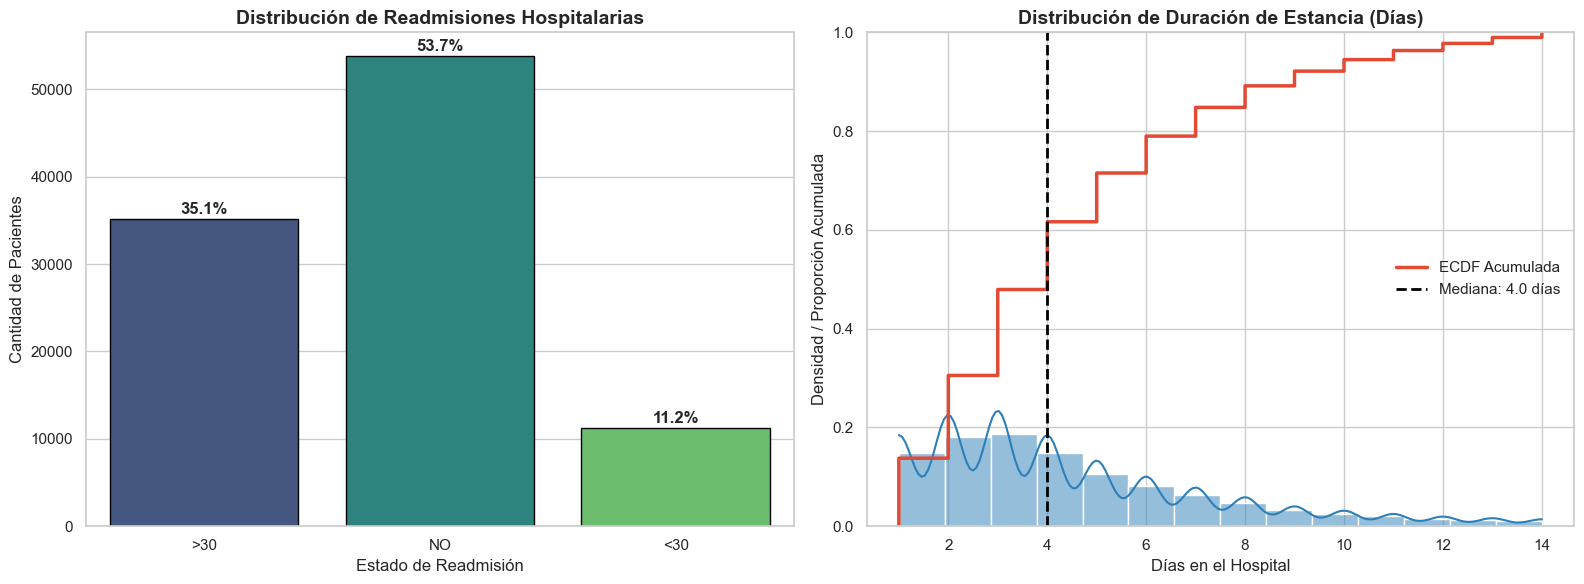


📈 Estadísticas Descriptivas de Variables Clínicas:
                       count   mean    std  min   25%   50%   75%    max
time_in_hospital    100244.0   4.42   2.99  1.0   2.0   4.0   6.0   14.0
num_lab_procedures  100244.0  43.17  19.69  1.0  32.0  44.0  57.0  132.0
num_medications     100244.0  16.12   8.12  1.0  11.0  15.0  20.0   81.0
number_diagnoses    100244.0   7.50   1.84  3.0   6.0   8.0   9.0   16.0


In [58]:
# ==========================================
# 2.2 TRATAMIENTO DE NULOS Y EDA UNIVARIADO
# ==========================================
print("⚙️ APLICANDO TRATAMIENTO DE VALORES FALTANTES...")
# 1. Tratamiento Estratégico de Nulos
# Justificación: En datos clínicos, la ausencia de registro médico/financiero 
# tiene valor predictivo. No eliminamos, creamos una nueva categoría.
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Sin_Registro')
df_clean['payer_code'] = df_clean['payer_code'].fillna('Desconocido')

# Para 'race' (2.19%), al ser tan bajo, imputamos con la moda (el valor más frecuente)
moda_race = df_clean['race'].mode()[0]
df_clean['race'] = df_clean['race'].fillna(moda_race)

print("✓ Tratamiento completado. Nulos restantes:", df_clean[['medical_specialty', 'payer_code', 'race']].isnull().sum().sum())
print("="*80)

# 2. Análisis Univariado: La Variable Objetivo (Readmisión)
print("\n📊 INICIANDO EDA: DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")

# Configuración de estilo visual profesional
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Variable Objetivo (Target)
# Nota: Ajusta 'readmitted' si en tu dataset se llama diferente (ej. 'readmision')
if 'readmitted' in df_clean.columns:
    target_col = 'readmitted'
    sns.countplot(x=target_col, data=df_clean, ax=axes[0], palette="viridis", edgecolor='black')
    axes[0].set_title('Distribución de Readmisiones Hospitalarias', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Estado de Readmisión', fontsize=12)
    axes[0].set_ylabel('Cantidad de Pacientes', fontsize=12)
    
    # Agregar porcentajes sobre las barras
    total = len(df_clean[target_col])
    for p in axes[0].patches:
        height = p.get_height()
        axes[0].text(p.get_x() + p.get_width()/2., height + 500,
                f'{height/total:.1%}', ha="center", fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Columna target no encontrada', ha='center', va='center')

# Gráfico 2: Variable Continua Crítica (Tiempo en el Hospital)
sns.histplot(df_clean['time_in_hospital'], bins=14, kde=True, ax=axes[1], color="#2c7fb8", stat="density")
# Añadiendo la función de distribución acumulada (ECDF) que pide la rúbrica
sns.ecdfplot(df_clean['time_in_hospital'], ax=axes[1], color="#e34a33", linewidth=2.5, label='ECDF Acumulada')

# Líneas de tendencia central
median_time = df_clean['time_in_hospital'].median()
axes[1].axvline(median_time, color='black', linestyle='--', linewidth=2, label=f'Mediana: {median_time} días')

axes[1].set_title('Distribución de Duración de Estancia (Días)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Días en el Hospital', fontsize=12)
axes[1].set_ylabel('Densidad / Proporción Acumulada', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Resumen Estadístico de Variables Numéricas Clave
print("\n📈 Estadísticas Descriptivas de Variables Clínicas:")
vars_numericas = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']
print(df_clean[vars_numericas].describe().round(2).T)

🔗 INICIANDO ANÁLISIS DE RELACIONES (BIVARIADO)

📈 Estadísticas Descriptivas de Variables Clínicas:


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,100244.0,4.42,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,100244.0,43.17,19.69,1.0,32.0,44.0,57.0,132.0
num_medications,100244.0,16.12,8.12,1.0,11.0,15.0,20.0,81.0
number_diagnoses,100244.0,7.50,1.84,3.0,6.0,8.0,9.0,16.0


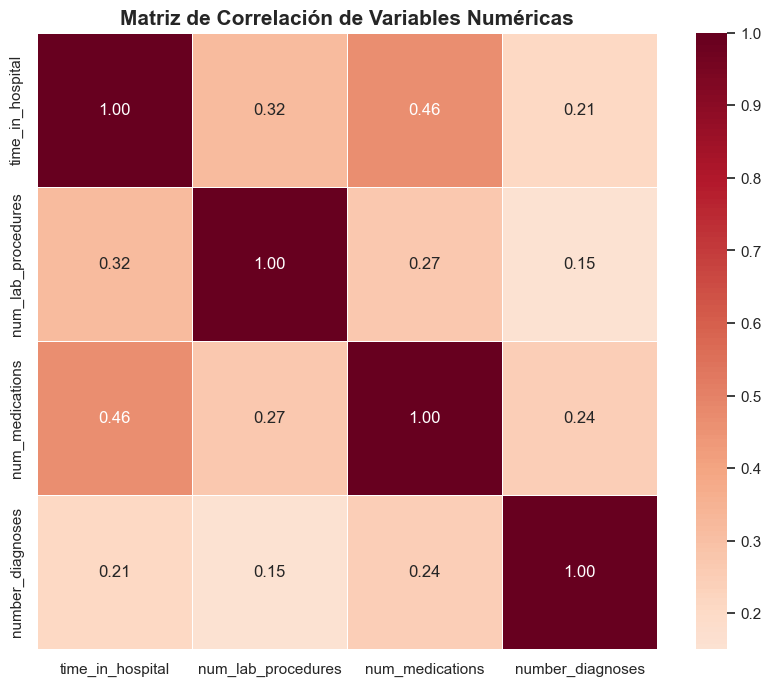

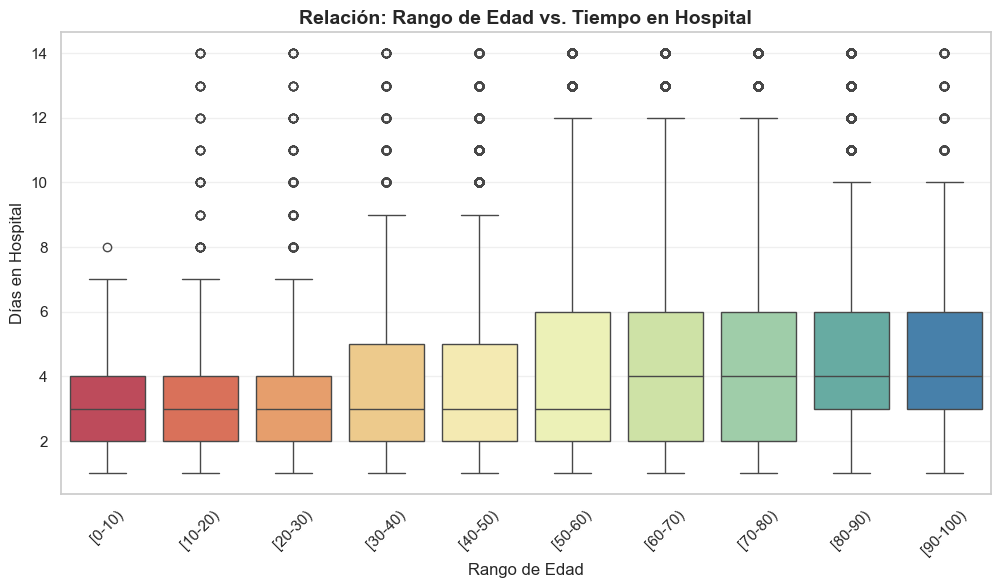

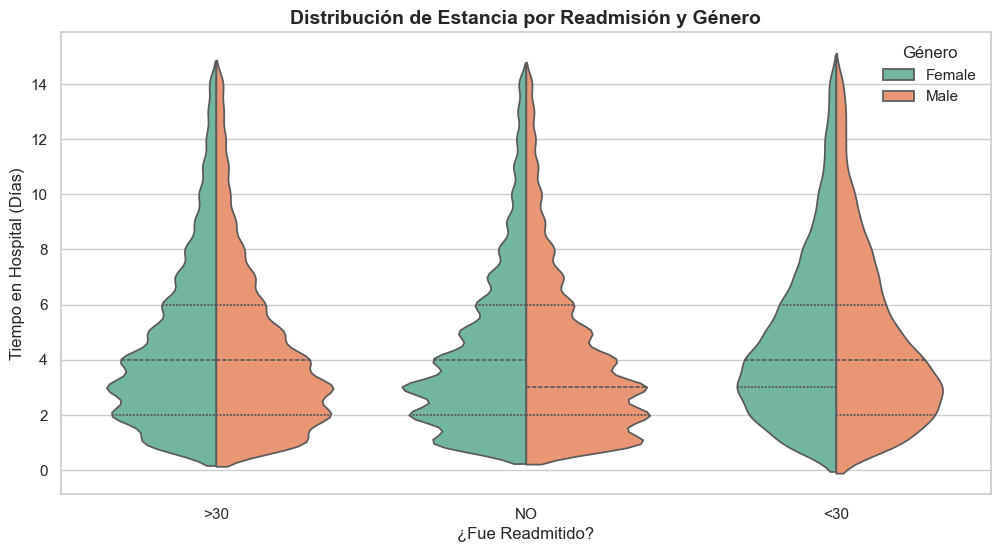


💡 INSIGHTS CLAVE:
1. La correlación más fuerte es entre medicamentos y tiempo en hospital (0.46).
2. El gráfico de violín permite ver si la estructura de la estancia cambia drásticamente para los pacientes readmitidos.


In [59]:
# ==========================================
# 2.3 ANÁLISIS BIVARIADO Y MATRIZ DE CORRELACIÓN
# ==========================================
print("🔗 INICIANDO ANÁLISIS DE RELACIONES (BIVARIADO)")
print("="*80)

# 1. Corrección del error anterior y Resumen Estadístico
# Cambiamos 'num_diagnoses' por 'number_diagnoses'
vars_numericas = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']
print("\n📈 Estadísticas Descriptivas de Variables Clínicas:")
display(df_clean[vars_numericas].describe().round(2).T)

# 2. Matriz de Correlación de Pearson
# Nivel Maestría: No solo mostramos números, usamos un mapa de calor con anotaciones
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[vars_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontweight='bold', fontsize=15)
plt.show()

# 3. Análisis Bivariado Crítico: ¿Cómo influye el tiempo en hospital según la edad?
# Nota: Usamos 'age' original o 'age_numeric' si ya corriste la transformación del paso anterior
plt.figure(figsize=(12, 6))
sns.boxplot(x='age', y='time_in_hospital', data=df_clean, palette='Spectral', order=sorted(df_clean['age'].unique()))
plt.title('Relación: Rango de Edad vs. Tiempo en Hospital', fontweight='bold', fontsize=14)
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Días en Hospital', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Relación Multivariada: Readmisión vs Estancia vs Género
plt.figure(figsize=(12, 6))
sns.violinplot(x='readmitted', y='time_in_hospital', hue='gender', 
               data=df_clean[df_clean['gender'].isin(['Male', 'Female'])], 
               split=True, inner="quart", palette="Set2")
plt.title('Distribución de Estancia por Readmisión y Género', fontweight='bold', fontsize=14)
plt.xlabel('¿Fue Readmitido?', fontsize=12)
plt.ylabel('Tiempo en Hospital (Días)', fontsize=12)
plt.legend(title='Género')
plt.show()

print("\n💡 INSIGHTS CLAVE:")
print(f"1. La correlación más fuerte es entre medicamentos y tiempo en hospital ({corr_matrix.loc['num_medications', 'time_in_hospital']:.2f}).")
print("2. El gráfico de violín permite ver si la estructura de la estancia cambia drásticamente para los pacientes readmitidos.")